# FINAL YEAR PROJECT

# GPT Models for Time-series Analysis and Forecasting.

<hr>

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timesfm
import torch

from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor # Chronos
import autogluon

from catboost import CatBoostRegressor

from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

```
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
```

**TimesFM Installation**

```
!pip install timesfm[torch]
!pip install -U huggingface_hub
```

**AutoGluon installation** 

```
!pip install autogluon.timeseries
```

<hr>

## Data

was collected from a road intersection in Iași, Romania where six HD IP cameras stream video at 25 FPS over a private 5G network to a GPU powered Multi-access Edge Computing node running a video analytics pipeline.

In [66]:
df = pd.read_csv('v100_yolov8x_live_001.csv')

In [67]:
display(df.head(5))

,fseqno,timestamp,car_count,inf_latency,model,gpu_util,gpu_power,network,gpu_mem,cpu_power,cpu_util,cpu_mem
0,0,1738041386,11,0.010372,yolov8x,1.0,40.0,0.0,0.0,78.900188,661.609829,17519.25
1,1,1738041386,11,0.471495,yolov8x,1.0,40.0,0.0,0.0,78.900188,661.609829,17519.25
2,2,1738041386,10,0.449062,yolov8x,1.0,40.0,0.0,0.0,78.900188,661.609829,17519.25
3,3,1738041386,11,0.384894,yolov8x,1.0,40.0,0.0,0.0,78.900188,661.609829,17519.25
4,4,1738041386,11,0.046002,yolov8x,1.0,40.0,0.0,0.0,78.900188,661.609829,17519.25


<hr>

In [68]:
fps_df = (df.groupby('timestamp')
            .size()
            .reset_index(name='frames'))

display(fps_df.head())

,timestamp,frames
0,1738041386,7
1,1738041387,18
2,1738041388,15
3,1738041389,14
4,1738041390,17


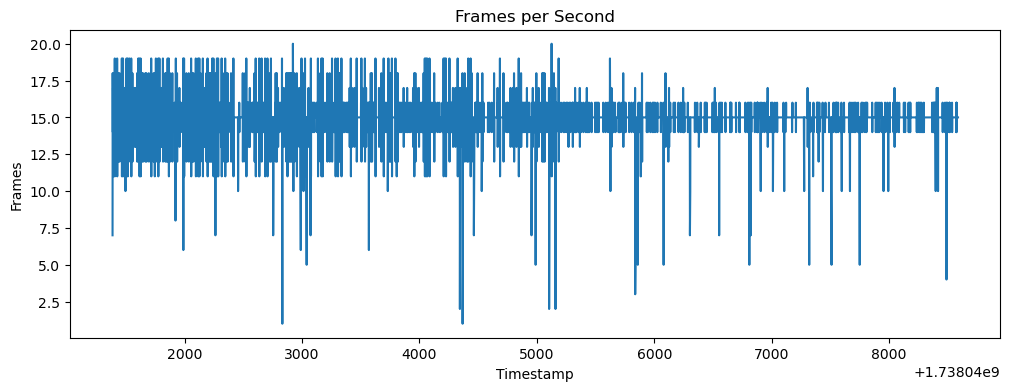

In [69]:
plt.figure(figsize=(12,4))
plt.plot(fps_df['timestamp'], fps_df['frames'])
plt.xlabel("Timestamp")
plt.ylabel("Frames")
plt.title("Frames per Second")
plt.show()

**On average we have almost 15 frames per one second**

In [70]:
display(fps_df['frames'].mean())

14.932978126752664

**We have 2 hours of data in total**

In [71]:
# data aggregated per second
per_sec = df.groupby("timestamp")["car_count"].mean()
per_sec = per_sec.to_frame().reset_index()

display(len(per_sec) / 60)

118.86666666666666

In [72]:
display(per_sec.head(10))

,timestamp,car_count
0,1738041386,11.285714
1,1738041387,11.666667
2,1738041388,13.400000
3,1738041389,12.928571
4,1738041390,12.352941
5,1738041391,12.800000
6,1738041392,11.266667
7,1738041393,11.733333
8,1738041394,11.533333
9,1738041395,8.722222


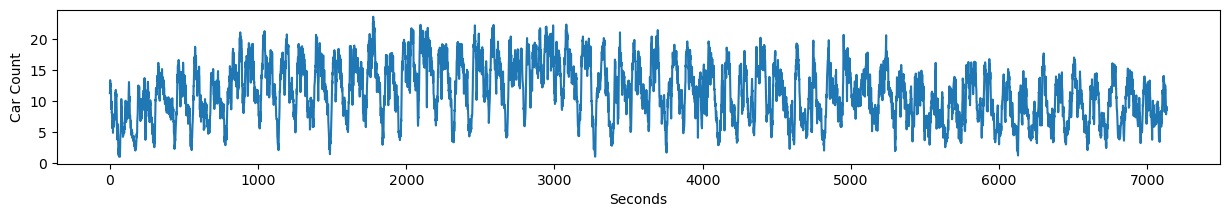

In [73]:
plt.figure(figsize=(15, 2))
plt.plot(per_sec["car_count"])
plt.xlabel("Seconds")
plt.ylabel("Car Count")
plt.show()

<hr>

## Features Engineering for GBM

**We will add lags, and rolling features. Commonly used practice for GBM forecasting.**

In [74]:
per_sec["dt"] = pd.to_datetime(per_sec["timestamp"], unit="s") 

In [75]:
for lag in [5, 15, 30, 60]:
    per_sec[f"car_count_lag_{lag}"] = per_sec['car_count'].shift(lag)

In [76]:
for window in [10, 30, 60]:
    per_sec[f"rllg_mean_{window}"] = per_sec["car_count"].shift(1).rolling(window).mean()
    per_sec[f"rllg_std_{window}"] = per_sec["car_count"].shift(1).rolling(window).std()

In [77]:
per_sec = per_sec.drop(['timestamp'], axis=1)

In [78]:
per_sec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7132 entries, 0 to 7131
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   car_count         7132 non-null   float64       
 1   dt                7132 non-null   datetime64[ns]
 2   car_count_lag_5   7127 non-null   float64       
 3   car_count_lag_15  7117 non-null   float64       
 4   car_count_lag_30  7102 non-null   float64       
 5   car_count_lag_60  7072 non-null   float64       
 6   rllg_mean_10      7122 non-null   float64       
 7   rllg_std_10       7122 non-null   float64       
 8   rllg_mean_30      7102 non-null   float64       
 9   rllg_std_30       7102 non-null   float64       
 10  rllg_mean_60      7072 non-null   float64       
 11  rllg_std_60       7072 non-null   float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 668.8 KB


<hr>

**WAPE score** <br>
Weighted Absolute Percentage Error: total absolute error divided by total actual values. <br>
* **MAPE** breaks when `y_true = 0`, **WAPE** doesn't
* **MAPE** gives equal weight to all observations, so small-value rows can dominate, **WAPE** is more stable

**`WAPE = 20%`** means total predicted volume is off by 20% relative to total actual volume.

In [79]:
def wape_nonzero(y_true, y_pred, eps=1e-9):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    m = (y_true != 0)
    if m.sum() == 0:
        return 0.0
    return np.sum(np.abs(y_true[m] - y_pred[m])) / (np.sum(np.abs(y_true[m])) + eps)

wape_nonzero_scorer = make_scorer(wape_nonzero, greater_is_better=False)

<hr>

## Train-Test Sets

**We will use 60 last seconds as a test set, because using actual frames will bring us to much noise for the models.**

In [80]:
# cut off date
cutoff_date = pd.Timestamp('2025-01-28 07:15:26')

# train-test split
train_df = per_sec[per_sec["dt"] <= cutoff_date].copy()
test_df  = per_sec[per_sec["dt"] > cutoff_date].copy()

**Train** set date period 

In [81]:
display(train_df["dt"].min())
display(train_df["dt"].max())

Timestamp('2025-01-28 05:16:26')

Timestamp('2025-01-28 07:15:26')

**Test** set date period 

In [82]:
display(test_df["dt"].min())
display(test_df["dt"].max())

Timestamp('2025-01-28 07:15:27')

Timestamp('2025-01-28 07:16:26')

In [83]:
# train features & target
X_train = train_df.drop(columns=['car_count'])
y_train = train_df['car_count']

# test features & target
X_test = test_df.drop(columns=['car_count'])
y_test = test_df['car_count']

<hr>

## Models Forecasting

### GBM

In [84]:
# time-series cross validation, used because regular CV is invalid
tscv = TimeSeriesSplit(n_splits=2)

# CatBoost model with GPU training type
catboost = CatBoostRegressor(task_type="GPU")

# parameter variation for GridSearch
param_grid = {
    "depth": [-1, 6, 10],
    "learning_rate": [0.01, 0.1, 0.5],
    "l2_leaf_reg": [30, 100],
    "iterations": [6000],
    "min_data_in_leaf": [50, 200, 800],
    "random_strength": [0.5, 2.0],
}

In [85]:
grid = GridSearchCV(
    estimator=catboost,
    param_grid=param_grid,
    cv=tscv,
    scoring={"wape": wape_nonzero_scorer, "mae": "neg_mean_absolute_error"},
    refit="wape",
    verbose=2,
    n_jobs=1
)

```
%%time

# model training
grid.fit(X_train, y_train, early_stopping_rounds=300, verbose=6000)
```

``` 
CPU times: total: 4h 2min 3s
Wall time: 4h 5min 2s
```

```
# trained model parameters
best_model = grid.best_estimator_

# saving model
best_model.save_model("gbm.cbm")
```

**4 hours for training GBM** 

<hr>

In [86]:
# model loading
catboost = CatBoostRegressor()
catboost.load_model("gbm.cbm")

In [87]:
# model parameters
catboost.get_params()

{'random_strength': 0.5,
 'od_wait': 300,
 'od_type': 'Iter',
 'verbose': 6000,
 'iterations': 6000,
 'loss_function': 'RMSE',
 'l2_leaf_reg': 100,
 'task_type': 'GPU',
 'depth': 6,
 'min_data_in_leaf': 50,
 'learning_rate': 0.01}

In [88]:
# prediction on test set
y_pred = catboost.predict(X_test)
test_df['pred_gbm'] = y_pred

<hr>

In [89]:
eps = 1e-9

# MAE
mae_gbm = np.mean(np.abs(y_test - y_pred))

# MAPE
mask = np.abs(y_test) > eps
mape_gbm = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

# WAPE
wape_gbm = wape_nonzero(y_test, y_pred) * 100

**naive baseline:** predict `car_count` using the value from 60s ago <br>
reuse the same `car_count_lag_60` column already built on the full series

In [90]:
# naive baseline
naive_pred = test_df["car_count_lag_60"].values.astype(np.float32)

mask_naive = ~np.isnan(naive_pred) & (np.abs(y_test) > eps)

mae_naive  = np.mean(np.abs(y_test[mask_naive] - naive_pred[mask_naive]))
mape_naive = np.mean(np.abs((y_test[mask_naive] - naive_pred[mask_naive]) / y_test[mask_naive])) * 100
wape_naive = wape_nonzero(y_test[mask_naive], naive_pred[mask_naive]) * 100

In [91]:
metrics = pd.DataFrame([[round(mae_naive, 2), round(mape_naive, 2), round(wape_naive, 2)], 
                        [round(mae_gbm, 2), round(mape_gbm, 2), round(wape_gbm, 2)], 
                        [0, 0, 0], 
                        [0, 0, 0]], 
                       index=["Naive Baseline", "GBM (Catboost)", "TimesFM", "Chronos"], 
                       columns=["MAE", "MAPE %", "WAPE %"])

In [92]:
display(metrics)

,MAE,MAPE %,WAPE %
Naive Baseline,3.21,42.70,36.90
GBM (Catboost),1.57,22.03,18.03
TimesFM,0.00,0.00,0.00
Chronos,0.00,0.00,0.00


<hr>

In [93]:
# list of additional GBM features
features_list = list(train_df.columns)

for i in ['car_count', 'dt']:
    features_list.remove(i)

display(features_list)

['car_count_lag_5',
 'car_count_lag_15',
 'car_count_lag_30',
 'car_count_lag_60',
 'rllg_mean_10',
 'rllg_std_10',
 'rllg_mean_30',
 'rllg_std_30',
 'rllg_mean_60',
 'rllg_std_60']

In [94]:
# removing GBM features from the data
train_df = train_df.drop(columns=features_list)
test_df = test_df.drop(columns=features_list)

<hr>

### TimesFM

In [95]:
# model loading
timesfm_model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

In [96]:
# predict horizon & max_context length
horizon = len(y_test)
max_context = len(y_train)

In [97]:
# model configure
timesfm_model.compile(
    timesfm.ForecastConfig(
        max_context=max_context, # historical context, train_df lenght
        max_horizon=256, # ceiling of forecasting horizon
        normalize_inputs=True,
        use_continuous_quantile_head=True, # 
        force_flip_invariance=True,
        infer_is_positive=False, # temperature can go negative
        fix_quantile_crossing=True,
    )
)

In [98]:
# context (train set) for model to look on
context = train_df['car_count'].values.astype(np.float32)

# forecasting
point_forecast, quantile_forecast = timesfm_model.forecast(
    horizon=horizon,
    inputs=[context], # single series -> list with one array
)

In [99]:
# predicted values
y_pred = point_forecast[0]
test_df['pred_timesfm'] = y_pred

In [100]:
test_df.head()

,car_count,dt,pred_gbm,pred_timesfm
7072,8.800000,2025-01-28 07:15:27,9.205884,9.151190
7073,8.600000,2025-01-28 07:15:28,9.669929,8.682796
7074,9.066667,2025-01-28 07:15:29,9.592892,8.171109
7075,8.000000,2025-01-28 07:15:30,8.855743,7.636539
7076,7.933333,2025-01-28 07:15:31,8.749394,7.282799


In [101]:
# metrics
mae_timesfm = np.mean(np.abs(y_test - y_pred))
mape_timesfm = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
wape_timesfm = wape_nonzero(y_test, y_pred) * 100

metrics.loc["TimesFM"] = [round(mae_timesfm, 2), round(mape_timesfm, 2), round(wape_timesfm, 2)]

In [102]:
display(metrics)

,MAE,MAPE %,WAPE %
Naive Baseline,3.21,42.70,36.90
GBM (Catboost),1.57,22.03,18.03
TimesFM,2.26,31.81,25.98
Chronos,0.00,0.00,0.00


<hr>

### Chronos

Pandas DFs to AutoGluon TimeSeriesDF 

In [103]:
train_df = train_df.copy()
train_df["item_id"] = "car_count"

train_data = TimeSeriesDataFrame.from_data_frame(
    train_df,
    id_column="item_id",
    timestamp_column="dt"
)

test_df = test_df.copy()
test_df["item_id"] = "car_count"

test_data = TimeSeriesDataFrame.from_data_frame(
    test_df,
    id_column="item_id",
    timestamp_column="dt"
)

<hr>

In [104]:
# model loading
model = TimeSeriesPredictor(
    prediction_length=horizon,
    target="car_count",
    freq="S",
).fit(
    train_data,
    hyperparameters={
        "Chronos2": {"context_length": None},},
    presets="chronos2",
)

Beginning AutoGluon training...
AutoGluon will save models to 'C:\Users\whois\Desktop\COMP494 Final Project (Thesis)\AutogluonModels\ag-20260630_144808'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.7
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.22631
CPU Count:          16
Pytorch Version:    2.5.1+cu121
CUDA Version:       12.1
GPU Memory:         GPU 0: 6.26/8.00 GB
Total GPU Memory:   Free: 6.26 GB, Allocated: 1.73 GB, Total: 8.00 GB
GPU Count:          1
Memory Avail:       14.69 GB / 31.19 GB (47.1%)
Disk Space Avail:   83.99 GB / 464.90 GB (18.1%)
Setting presets to: chronos2

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'freq': 'S',
 'hyperparameters': {'Chronos2': {'context_length': None}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 60,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'ref

In [105]:
pred = model.predict(train_data, 
                     model='Chronos2',)

data with frequency 'IRREG' has been resampled to frequency 'S'.


In [106]:
# saving predictions
y_pred = pred['mean'].values.astype(np.float32)
test_df['pred_chronos'] = y_pred

In [107]:
# metrics
mae_chronos = np.mean(np.abs(y_test - y_pred))
mape_chronos = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
wape_chronos = wape_nonzero(y_test, y_pred) * 100

metrics.loc["Chronos"] = [round(mae_chronos, 2), round(mape_chronos, 2), round(wape_chronos, 2)]

In [108]:
display(metrics)

,MAE,MAPE %,WAPE %
Naive Baseline,3.21,42.70,36.90
GBM (Catboost),1.57,22.03,18.03
TimesFM,2.26,31.81,25.98
Chronos,1.73,24.82,19.87


<hr>

### Chronos Fine-Tuned

In [109]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.5.1+cu121
True
NVIDIA GeForce RTX 4060


<hr>

```
# model loading
model = TimeSeriesPredictor(
    prediction_length=horizon,
    target="car_count",
    freq="S",
    path="saved_models/chronos2_lora",
).fit(
    train_data,
    hyperparameters={
        "Chronos2": {"fine_tune":True, 'fine_tune_mode':'lora', "ag_args":{"name_suffix": "FineTuned"}}},
    presets="chronos2",
)
```

**280 seconds for fine-tuning Chronos** 

In [110]:
# loading tuned Chronos model
model = TimeSeriesPredictor.load("saved_models/chronos2_lora")

Loading predictor from path C:\Users\whois\Desktop\COMP494 Final Project (Thesis)\saved_models\chronos2_lora


In [111]:
pred = model.predict(train_data, 
                     model='Chronos2FineTuned',)

data with frequency 'IRREG' has been resampled to frequency 'S'.


In [112]:
# saving predictions
y_pred = pred['mean'].values.astype(np.float32)
test_df['pred_chronos_ft'] = y_pred

In [113]:
# metrics
mae_chronos_ft = np.mean(np.abs(y_test - y_pred))
mape_chronos_ft = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
wape_chronos_ft = wape_nonzero(y_test, y_pred) * 100

metrics.loc["Chronos Fine-Tuned"] = [round(mae_chronos_ft, 2), round(mape_chronos_ft, 2), round(wape_chronos_ft, 2)]

In [114]:
# final metrics dataset
display(metrics)

,MAE,MAPE %,WAPE %
Naive Baseline,3.21,42.70,36.90
GBM (Catboost),1.57,22.03,18.03
TimesFM,2.26,31.81,25.98
Chronos,1.73,24.82,19.87
Chronos Fine-Tuned,1.70,23.33,19.57


<hr>

## Forecasting Analysis

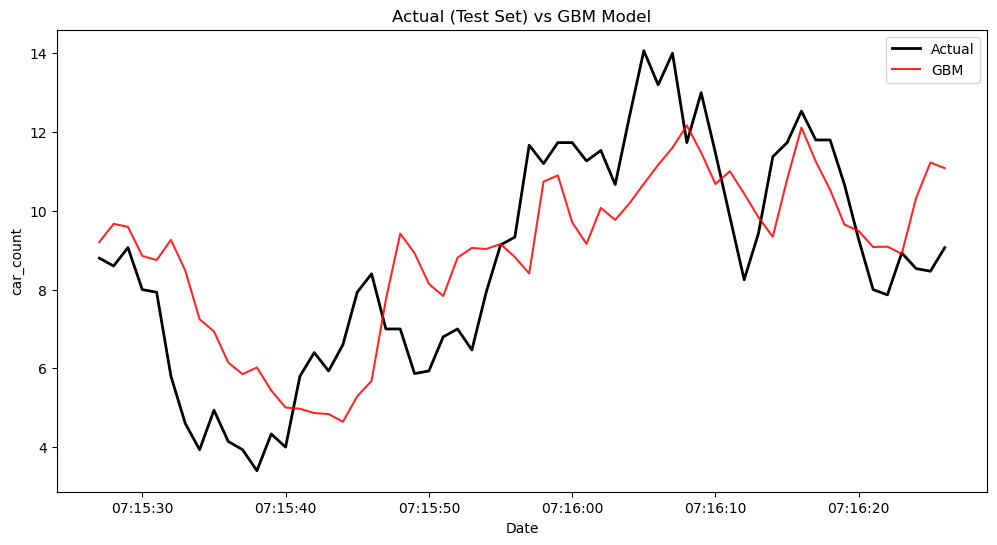

In [115]:
plt.figure(figsize=(12, 6))
plt.plot(test_df['dt'], y_test, label='Actual', c='0', linewidth=2)
plt.plot(test_df['dt'], test_df['pred_gbm'], label='GBM', c='red', alpha=0.85)
plt.title('Actual (Test Set) vs GBM Model')
plt.xlabel('Date')
plt.ylabel('car_count')
plt.legend()
plt.show()

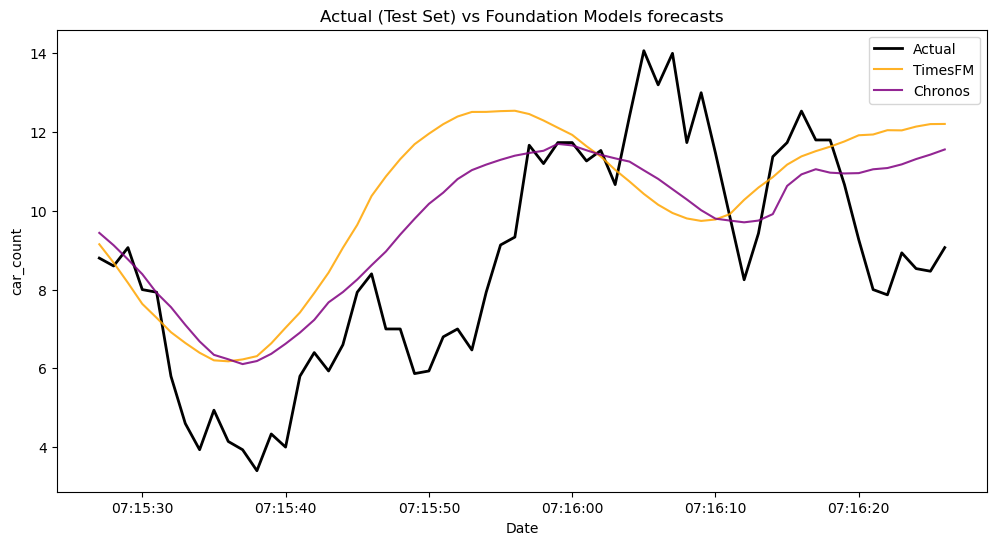

In [116]:
plt.figure(figsize=(12, 6))
plt.plot(test_df['dt'], y_test, label='Actual', c='0', linewidth=2)
plt.plot(test_df['dt'], test_df['pred_timesfm'], label='TimesFM', c='orange', alpha=0.85)
plt.plot(test_df['dt'], test_df['pred_chronos'], label='Chronos', c='purple', alpha=0.85)
plt.title('Actual (Test Set) vs Foundation Models forecasts')
plt.xlabel('Date')
plt.ylabel('car_count')
plt.legend()
plt.show()

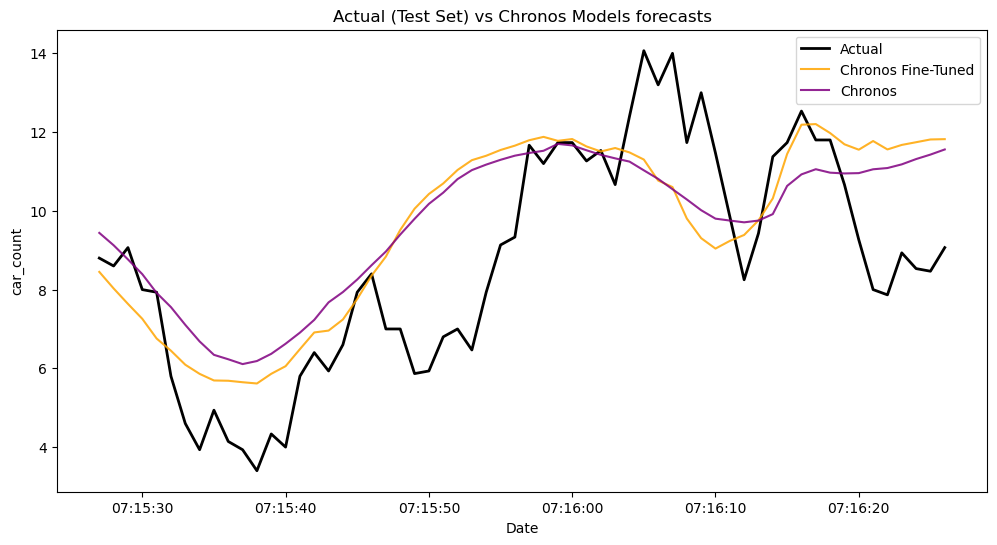

In [117]:
plt.figure(figsize=(12, 6))
plt.plot(test_df['dt'], y_test, label='Actual', c='0', linewidth=2)
plt.plot(test_df['dt'], test_df['pred_chronos_ft'], label='Chronos Fine-Tuned', c='orange', alpha=0.85)
plt.plot(test_df['dt'], test_df['pred_chronos'], label='Chronos', c='purple', alpha=0.85)
plt.title('Actual (Test Set) vs Chronos Models forecasts')
plt.xlabel('Date')
plt.ylabel('car_count')
plt.legend()
plt.show()

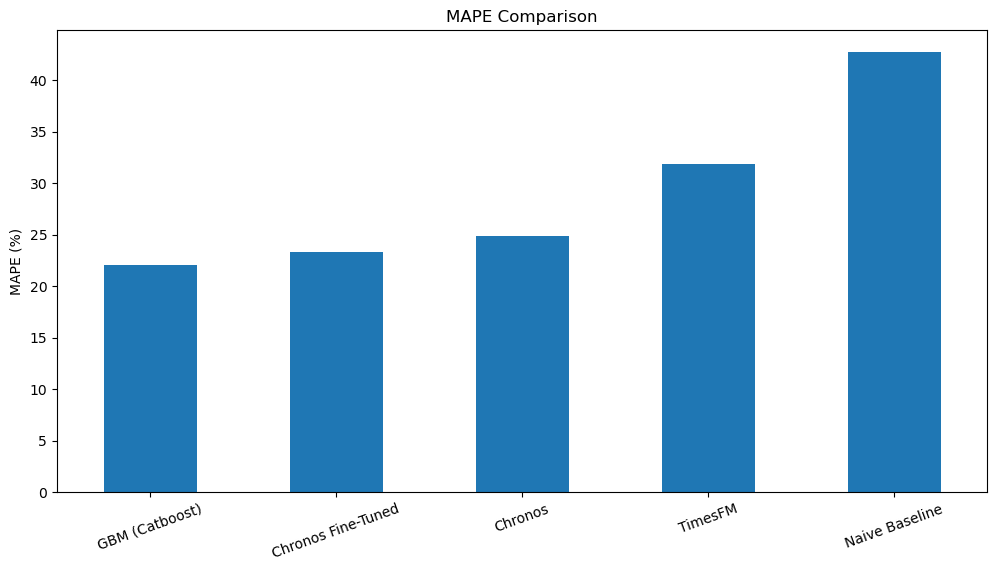

In [127]:
plt.figure(figsize=(12,6))
metrics['MAPE %'].sort_values(ascending=True).plot(kind='bar')
plt.ylabel('MAPE (%)')
plt.title('MAPE Comparison')
plt.xticks(rotation=20)
plt.show()

<hr>

# Results

* All the models are doing better than chosen Naive baseline (predict same as 60 seconds before)
* Foundation models `TimesFM` & `Chronos` are producing visibly **smooth forecasts** that track the trend of series, but they are **failing to reproduce short term volatility** (spikes on the chart)
* On the other hand, `GBM` model was **the best from all of them**, but it requires feature engineering `lags` & `rollings`, and **time-consuming** training/hyperparameter search (4 hours total)
* `Chronos Fine-Tuned` on LoRA (Low-Rank Adaptation) adapters is showing **slightly better perfomance** than zero-shot `Chronos`, we can also see this on the chart: prediction is trying to capture short fluctuations and becomes a little bit less smooth. We assume this could be even better if we had `>100 time series` as AutoGluon suggesting:
    * _We recommend fine-tuning only when you have a reasonable number of time series and sufficient historical data (e.g., >100 time series with a median history length larger than 3 * prediction_length), as limited data can lead to overfitting or degraded performance. If you observe degraded accuracy, we recommend increasing the size of the training data and experimenting with different fine-tuning hyperparameters._
   
Foundation models demonstrated competitive forecasting performance with considerably less manual feature engineering compared to traditional methods such as GBM, this represents a practical trade-off between implementation effort and forecasting accuracy. <br><br>
Additionally, there are performance improvements from TimesFM to Chronos and from zero-shot to fine-tuned Chronos indicating the advancement of foundation models, we can suggest that they will play an increasingly important role in time-series forecasting as the technology continues to mature.


In [118]:
display(metrics)

,MAE,MAPE %,WAPE %
Naive Baseline,3.21,42.70,36.90
GBM (Catboost),1.57,22.03,18.03
TimesFM,2.26,31.81,25.98
Chronos,1.73,24.82,19.87
Chronos Fine-Tuned,1.70,23.33,19.57
